In [5]:
import scipy.io as sio
import pandas as pd
import numpy as np
import sys, os
import torch
project_root = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
from data_classes.decomposition import Extract_Features

In [6]:
torch.manual_seed(42)
device = torch.device(
                    "cuda"
                    if torch.cuda.is_available()
                    else "mps" if torch.backends.mps.is_available() else "cpu"
                )
print(f"Using {device}")

# load & preprocess
data = sio.loadmat('../data/mine_impact_data_2019.mat')
samps = pd.DataFrame(data['x'].T)
labs  = pd.DataFrame(data['y'].T, columns=['y'])
df = pd.concat([samps, labs], axis=1).dropna().sample(frac=1, random_state=42)


Using cuda


In [7]:
shuffled_df = df.sample(frac=1, random_state=42).reset_index(drop=True)

df_X = shuffled_df.iloc[:, :-1]
df_Y = shuffled_df.iloc[:, -1]

data = Extract_Features(df_X, df_Y, feature="raw")
print(data.get_samples().shape, data.get_labels().shape)

(3309, 36000) (3309,)


[INFO] EPOCH: 1/25
Train loss: 0.630465, Train accuracy: 0.6617
[INFO] EPOCH: 2/25
Train loss: 0.560539, Train accuracy: 0.6717
[INFO] EPOCH: 3/25
Train loss: 0.488736, Train accuracy: 0.7500
[INFO] EPOCH: 4/25
Train loss: 0.425357, Train accuracy: 0.8090
[INFO] EPOCH: 5/25
Train loss: 0.347027, Train accuracy: 0.8520
[INFO] EPOCH: 6/25
Train loss: 0.297030, Train accuracy: 0.8693
[INFO] EPOCH: 7/25
Train loss: 0.258591, Train accuracy: 0.9023
[INFO] EPOCH: 8/25
Train loss: 0.233361, Train accuracy: 0.9093
[INFO] EPOCH: 9/25
Train loss: 0.236293, Train accuracy: 0.9093
[INFO] EPOCH: 10/25
Train loss: 0.200988, Train accuracy: 0.9250
[INFO] EPOCH: 11/25
Train loss: 0.174051, Train accuracy: 0.9380
[INFO] EPOCH: 12/25
Train loss: 0.166073, Train accuracy: 0.9427
[INFO] EPOCH: 13/25
Train loss: 0.153433, Train accuracy: 0.9430
[INFO] EPOCH: 14/25
Train loss: 0.121451, Train accuracy: 0.9540
[INFO] EPOCH: 15/25
Train loss: 0.121628, Train accuracy: 0.9580
[INFO] EPOCH: 16/25
Train loss: 0.

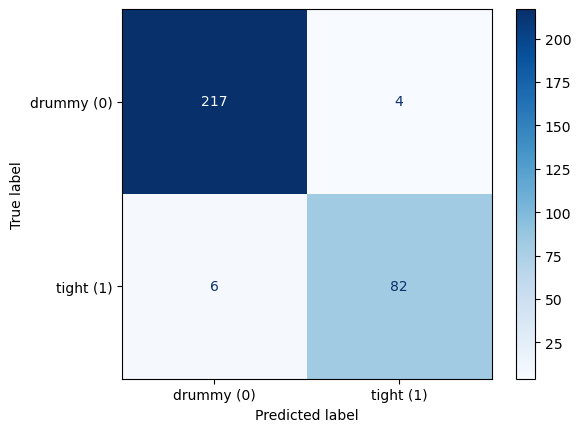


Classification Report:
               precision    recall  f1-score   support

  drummy (0)       0.97      0.98      0.98       221
   tight (1)       0.95      0.93      0.94        88

    accuracy                           0.97       309
   macro avg       0.96      0.96      0.96       309
weighted avg       0.97      0.97      0.97       309



In [8]:
import models.classification as classify
import models.loops as loops
import models.models as models

train_idx = list(range(0, 3000))
test_idx = list(range(3000,3309))

train_data = torch.utils.data.Subset(data, train_idx)
test_data = torch.utils.data.Subset(data, test_idx)

batch_size = 30

train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size, shuffle=True)

model = models.Convolution()

loops.train(model=model, model_path="./model_paths/convolution.pth", train_loader=train_loader, batch_size=batch_size, lr=1e-3,weight_decay=0, optim="adam", epochs=25)

loops.test(model_path="./model_paths/convolution.pth", test_loader=test_loader, report=True)

In [9]:

m = torch.nn.MaxPool1d(10)
input = torch.randn(1,1,36000)
output = m(input)

print("Input shape:", input.shape)
print("Output shape:", output.shape)

Input shape: torch.Size([1, 1, 36000])
Output shape: torch.Size([1, 1, 3600])
